## 1. Imports 

Nesse módulo, são definidos os imports e as variáveis globais utilizadas ao longo do projeto



In [203]:
import os, re, json, hashlib
from collections import defaultdict
from typing import Dict, Tuple, Optional, List

import numpy as np
import pandas as pd

from unidecode import unidecode

from langchain_community.document_loaders import DirectoryLoader, TextLoader
from langchain_community.vectorstores import FAISS
from langchain.embeddings import HuggingFaceEmbeddings

from sentence_transformers import SentenceTransformer

import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_distances
from sklearn.preprocessing import normalize

os.environ["TOKENIZERS_PARALLELISM"] = "false"

# caminhos do teu ambiente
CSV_PATH  = r"C:\\Users\\DELL\\projetos\\embeddings\\src\\ranking_musical_completo_1928-2024.csv"
BASE_DIR  = r"data/letras"
FAISS_DIR = r"C:\\tmp\\faiss_db"
MANIFEST  = os.path.join(FAISS_DIR, "manifest.json")
EMB_MODEL = "sentence-transformers/all-MiniLM-L6-v2"

os.makedirs(FAISS_DIR, exist_ok=True)

# embedding compartilhado
embedding = HuggingFaceEmbeddings(
    model_name=EMB_MODEL,
    encode_kwargs={"batch_size": 16, "normalize_embeddings": True}
)

In [204]:
# %% 2. Utilitários de leitura e normalização de nomes

_DEF_COL_ANO = ["Ano", "ano"]
_DEF_COL_ART = ["Artista", "artista"]
_DEF_COL_MUS = ["Música", "Musica", "musica", "música"]

def sanitize_token(s: str) -> str:
    s = "" if s is None else str(s)
    s = s.strip()
    s = s.replace("&", " e ")
    s = unidecode(s)
    s = re.sub(r'[\\/*?:"<>|]', "", s)
    s = re.sub(r"\s+", "_", s)
    return s

def safe_read_csv(path: str) -> pd.DataFrame:
    for enc in ("utf-8", "utf-8-sig", "latin-1"):
        try:
            return pd.read_csv(path, encoding=enc)
        except Exception:
            continue
    raise RuntimeError(f"Não foi possível ler o CSV em {path}")

def resolve_cols(df: pd.DataFrame) -> Tuple[str, str, str]:
    def pick(opts):
        for c in df.columns:
            if c in opts:
                return c
        # busca por nome em lower
        lower = {c.lower(): c for c in df.columns}
        for opt in opts:
            if opt.lower() in lower:
                return lower[opt.lower()]
        raise KeyError(f"Coluna não encontrada. Opções aceitas: {opts}")
    col_ano = pick(_DEF_COL_ANO)
    col_art = pick(_DEF_COL_ART)
    col_mus = pick(_DEF_COL_MUS)
    return col_ano, col_art, col_mus



In [205]:
# %% 3. Ler CSV de referência e montar índice (ano, artista, música)

df_csv = safe_read_csv(CSV_PATH)
col_ano, col_art, col_mus = resolve_cols(df_csv)

# padroniza ano
_df = df_csv.copy()
_df[col_ano] = pd.to_numeric(_df[col_ano], errors="coerce").astype("Int64")
_df = _df.dropna(subset=[col_ano])

def build_csv_index(df: pd.DataFrame) -> Dict[Tuple[int, str, str], list]:
    idx = defaultdict(list)
    for r in df.itertuples(index=False):
        ano = getattr(r, col_ano)
        if pd.isna(ano):
            continue
        ano = int(ano)
        artista_orig = str(getattr(r, col_art))
        musica_orig  = str(getattr(r, col_mus))
        key = (
            ano,
            sanitize_token(artista_orig),
            sanitize_token(musica_orig),
        )
        idx[key].append((artista_orig, musica_orig))
    return dict(idx)

CSV_INDEX = build_csv_index(_df)
print(f"Linhas válidas no CSV: {len(_df)} | Chaves no índice: {len(CSV_INDEX):,}")


Linhas válidas no CSV: 2492 | Chaves no índice: 849


In [206]:
# %% 4. Parser de metadados a partir do caminho do arquivo

def parse_meta_from_path_csv(path: str, base_dir: str, csv_index=None) -> Dict:
    rel = os.path.relpath(path, base_dir)
    parts = rel.split(os.sep)

    # tentativa de década vinda do diretório
    decada_raw = parts[0] if len(parts) >= 1 else None

    # ano: primeiro diretório após a década que tenha 4 dígitos
    ano = None
    for p in parts[1:]:
        m = re.search(r"\b(\d{4})\b", p)
        if m:
            ano = int(m.group(1))
            break

    base_raw = os.path.splitext(os.path.basename(path))[0]
    base_san = sanitize_token(base_raw)

    artista = None
    musica = None

    if csv_index is not None and ano is not None:
        if "__" in base_san:
            a_san, m_san = base_san.split("__", 1)
            key = (ano, a_san, m_san)
            if key in csv_index:
                artista, musica = csv_index[key][0]
        else:
            tokens = base_san.split("_")
            for i in range(1, len(tokens)):
                a_san = "_".join(tokens[:i])
                m_san = "_".join(tokens[i:])
                key = (ano, a_san, m_san)
                if key in csv_index:
                    artista, musica = csv_index[key][0]
                    break

    # fallback
    if artista is None or musica is None:
        if "_" in base_raw:
            artista_guess, musica_guess = base_raw.rsplit("_", 1)
        else:
            artista_guess, musica_guess = base_raw, base_raw
        artista = artista or artista_guess.replace("_", " ")
        musica  = musica  or musica_guess.replace("_", " ")

    # normalizar década
    if decada_raw is None and ano is not None:
        decada = int(ano // 10 * 10)
    else:
        if decada_raw and re.match(r"\d{4}s?", decada_raw):
            # "1970s" -> 1970
            dec = int(re.findall(r"\d{4}", decada_raw)[0])
            decada = int(dec // 10 * 10)
        else:
            # mantém como está (pode ser rótulo custom)
            decada = decada_raw

    return {
        "source": path,
        "relative_path": rel,
        "decada": decada,
        "ano": ano,
        "file_name": base_raw,
        "file_name_san": base_san,
        "artista": artista,
        "musica": musica,
    }

In [207]:
# %% 5. Carregar .txt e aplicar metadados

loader = DirectoryLoader(
    BASE_DIR,
    glob="**/*.txt",
    loader_cls=TextLoader,
    show_progress=True,
    loader_kwargs={"encoding": "utf-8"}
)
docs_all = loader.load()
docs = [d for d in docs_all if d.page_content and d.page_content.strip()]

for d in docs:
    src = d.metadata.get("source")
    try:
        meta = parse_meta_from_path_csv(src, BASE_DIR, csv_index=CSV_INDEX)
    except Exception as e:
        meta = {"parse_error": str(e)}
    d.metadata.update(meta)
    d.metadata["content_md5"] = hashlib.md5(d.page_content.strip().encode("utf-8")).hexdigest()

print(f"Documentos com letra carregados: {len(docs)} (de {len(docs_all)})")
if docs:
    print({k: docs[0].metadata.get(k) for k in ["decada","ano","artista","musica","relative_path"]})

100%|██████████| 832/832 [00:00<00:00, 3689.71it/s]

Documentos com letra carregados: 168 (de 832)
{'decada': 'letras', 'ano': 1928, 'artista': 'Pixinguinha', 'musica': 'Carinhoso', 'relative_path': 'letras\\1920s\\1928\\Pixinguinha__Carinhoso.txt'}


In [208]:
# %% 6. Construir corpus tabular (df_corpus)

def build_df_corpus(_docs) -> pd.DataFrame:
    rows = []
    for d in _docs:
        m = d.metadata
        rows.append({
            "path": m.get("source"),
            "decada": m.get("decada"),
            "ano": m.get("ano"),
            "artista": m.get("artista"),
            "musica": m.get("musica"),
            "texto": d.page_content.strip()
        })
    df = pd.DataFrame(rows)

    # força ano e década
    df = df.dropna(subset=["texto"])
    df["ano"] = pd.to_numeric(df["ano"], errors="coerce")
    # década: se não vier numérica, deriva do ano
    def _fix_decada(row):
        d = row["decada"]
        a = row["ano"]
        if pd.notna(d) and str(d).isdigit():
            return int(d)
        if pd.notna(a):
            return int(a // 10 * 10)
        return np.nan

    df["decada"] = df.apply(_fix_decada, axis=1)
    df = df.dropna(subset=["ano", "decada"]).reset_index(drop=True)
    df["ano"] = df["ano"].astype(int)
    df["decada"] = df["decada"].astype(int)

    print(f"Corpus construído: {len(df)} músicas com metadados válidos")
    return df

df_corpus = build_df_corpus(docs)
df_corpus.head(3)


Corpus construído: 168 músicas com metadados válidos


,path,decada,ano,artista,musica,texto
0,data\letras\letras\1920s\1928\Pixinguinha__Car...,1920,1928,Pixinguinha,Carinhoso,"Meu coração, não sei por quê\nBate feliz quand..."
1,data\letras\letras\1920s\1929\Mario_Reis__Gost...,1920,1929,Mário Reis,Gosto Que Me Enrosco,Não se deve amar sem ser amado\nÉ melhor morre...
2,data\letras\letras\1920s\1929\Mario_Reis__Jura...,1920,1929,Mário Reis,Jura,"Jura\nJura, jura pelo Senhor\nJura\nPela image..."


In [209]:
# %% 7. Criar/atualizar índice FAISS (busca semântica)

faiss_db = FAISS.from_documents(docs, embedding)
faiss_db.save_local(FAISS_DIR)
print("FAISS index salvo em:", FAISS_DIR)

def load_manifest() -> dict:
    if os.path.exists(MANIFEST):
        with open(MANIFEST, "r", encoding="utf-8") as f:
            return json.load(f)
    return {}

def save_manifest(manifest: dict):
    with open(MANIFEST, "w", encoding="utf-8") as f:
        json.dump(manifest, f, ensure_ascii=False, indent=2)

def file_md5(text: str) -> str:
    return hashlib.md5(text.encode("utf-8")).hexdigest()

def incremental_update():
    manifest = load_manifest()
    loader = DirectoryLoader(
        BASE_DIR,
        glob="**/*.txt",
        loader_cls=TextLoader,
        show_progress=True,
        loader_kwargs={"encoding": "utf-8"}
    )
    _docs = loader.load()
    cand = [d for d in _docs if d.page_content and d.page_content.strip()]
    to_add = []
    for d in cand:
        text = d.page_content.strip()
        md5 = file_md5(text)
        path = d.metadata["source"]
        if manifest.get(path) == md5:
            continue
        meta = parse_meta_from_path_csv(path, BASE_DIR, csv_index=CSV_INDEX)
        d.metadata.update(meta)
        d.metadata["content_md5"] = md5
        to_add.append(d)
        manifest[path] = md5

    if not to_add:
        print("Nada novo/alterado para indexar.")
        return

    faiss_db = FAISS.load_local(FAISS_DIR, embedding, allow_dangerous_deserialization=True)
    faiss_db.add_documents(to_add)
    faiss_db.save_local(FAISS_DIR)
    save_manifest(manifest)
    print(f"Incremento aplicado: {len(to_add)} documentos.")

FAISS index salvo em: C:\\tmp\\faiss_db


In [220]:
# %% 8. Geração de embeddings em lote (para análise temporal)

emb_model = SentenceTransformer(EMB_MODEL)
emb_matrix = emb_model.encode(
    df_corpus["texto"].tolist(),
    convert_to_numpy=True,
    show_progress_bar=True
)
print("Embeddings gerados:", emb_matrix.shape)


Batches:   0%|          | 0/6 [00:00<?, ?it/s]

Embeddings gerados: (168, 384)


In [211]:
def buscar_texto(query: str, k: int = 5):
    """
    Busca textual semântica no índice FAISS, mostrando as músicas mais próximas da consulta.
    """
    print(f"\n🔎 {query}\n")
    faiss_db = FAISS.load_local(FAISS_DIR, embedding, allow_dangerous_deserialization=True)
    results = faiss_db.similarity_search(query, k=k)
    for i, r in enumerate(results, 1):
        m = r.metadata
        prev = (r.page_content[:160] + "…") if len(r.page_content) > 160 else r.page_content
        print(f"[{i}] {m.get('decada','?')}/{m.get('ano','?')} — {m.get('artista','?')} — {m.get('musica','?')}")
        print("    ", m.get('source','?'))
        print("    ", prev, "\n")


# Exemplo de busca
buscar_texto("amor e saudade", 5)


def _build_df_corpus(_docs) -> pd.DataFrame:
    """
    Constrói um DataFrame a partir dos documentos carregados com metadados limpos e estruturados.
    Corrige décadas inválidas (ex.: 'letras') derivando do ano quando necessário.
    """
    rows = []
    for d in _docs:
        m = d.metadata
        rows.append({
            "path": m.get("source"),
            "decada": m.get("decada"),
            "ano": m.get("ano"),
            "artista": m.get("artista"),
            "musica": m.get("musica"),
            "texto": d.page_content.strip()
        })

    df = pd.DataFrame(rows)

    # --- Correções de década ---
    # Substitui valores não numéricos por NaN
    df["decada"] = df["decada"].apply(
        lambda d: int(d) if pd.notna(d) and str(d).isdigit() else np.nan
    )

    # Deriva década a partir do ano, quando ausente
    df.loc[df["decada"].isna() & df["ano"].notna(), "decada"] = (
        df.loc[df["decada"].isna() & df["ano"].notna(), "ano"]
        .astype(float)
        .floordiv(10)
        .mul(10)
        .astype(int)
    )

    # Converte tipos
    df["ano"] = df["ano"].astype("Int64")
    df["decada"] = df["decada"].astype("Int64")

    # Remove linhas sem texto ou ano válido
    df = df.dropna(subset=["texto", "ano"]).reset_index(drop=True)

    print(f"✅ Corpus construído: {len(df)} músicas com metadados válidos")
    print(df.head(3)[["ano", "decada", "artista", "musica"]])

    return df


# --- Construção do corpus ---
df_corpus = _build_df_corpus(docs)



🔎 amor e saudade

[1] letras/2003 — Rita Lee — Amor e Sexo
     data\letras\letras\2000s\2003\Rita_Lee__Amor_e_Sexo.txt
     mor é um livro
Sexo é esporte
Sexo é escolha
Amor é sorte

Amor é pensamento
Teorema
Amor é novela
Sexo é cinema

Sexo é imaginação
Fantasia
Amor é prosa
Sexo é… 

[2] letras/2005 — Leonardo — A Desconhecida
     data\letras\letras\2000s\2005\Leonardo__A_Desconhecida.txt
     Numa tarde tão linda de sol
Ela me apareceu
Com sorriso tão triste e olhar
Tão profundo, já sofreu
Suas mãos tão pequenas e frias
Sua voz tropeçava também
E fal… 

[3] letras/2005 — Babado Novo — Doce Desejo
     data\letras\letras\2000s\2005\Babado_Novo__Doce_Desejo.txt
     Tá no jeito de olhar
Tá no gosto do beijo
Na expressão do sorriso
Tá no meu paraíso
Tá no doce desejo

Tá no cheiro da flor
Estampado na cara
Tá na força do amo… 

[4] letras/2004 — Zezé di Camargo & Luciano — O Nosso Amor é Ouro
     data\letras\letras\2000s\2004\Zeze_di_Camargo_e_Luciano__O_Nosso_Amor_e_Ouro.txt
    

In [212]:
df_corpus

,path,decada,ano,artista,musica,texto
0,data\letras\letras\1920s\1928\Pixinguinha__Car...,1920,1928,Pixinguinha,Carinhoso,"Meu coração, não sei por quê\nBate feliz quand..."
1,data\letras\letras\1920s\1929\Mario_Reis__Gost...,1920,1929,Mário Reis,Gosto Que Me Enrosco,Não se deve amar sem ser amado\nÉ melhor morre...
2,data\letras\letras\1920s\1929\Mario_Reis__Jura...,1920,1929,Mário Reis,Jura,"Jura\nJura, jura pelo Senhor\nJura\nPela image..."
3,data\letras\letras\1930s\1930\Carmen_Miranda__...,1930,1930,Carmen Miranda,Ta-hí (Pra Você Gostar de Mim),"Taí!\nEu fiz tudo pra você gostar de mim\nÓ, m..."
4,data\letras\letras\1930s\1933\Aurora_Miranda_e...,1930,1933,Aurora Miranda & André Filho,Cidade Maravilhosa,Cidade maravilhosa\nCheia de encantos mil\nCid...
...,...,...,...,...,...,...
163,data\letras\letras\2000s\2006\Leonardo__Deixar...,2000,2006,Leonardo,Deixaria Tudo,Já tentei te convencer de tudo quanto é jeito\...
164,data\letras\letras\2000s\2006\Madonna__Hung_Up...,2000,2006,Madonna,Hung Up,Time goes by so slowly\nTime goes by so slowly...
165,data\letras\letras\2000s\2006\Marcelo_D2__Qual...,2000,2006,Marcelo D2,Qual é?,Hiemolai Hiemolai!\nHiemolai Iê!\n\nHiemolai H...
166,data\letras\letras\2000s\2006\MC_Leozinho__Ela...,2000,2006,MC Leozinho,Ela Só Pensa em Beijar,"Se ela dança, eu danço\nSe ela dança, eu danço..."


In [213]:

def localizar(artista: Optional[str] = None, musica: Optional[str] = None) -> pd.DataFrame:
    mask = pd.Series([True] * len(df_corpus))
    if artista:
        mask &= df_corpus["artista"].fillna("").str.contains(artista, case=False, na=False)
    if musica:
        mask &= df_corpus["musica"].fillna("").str.contains(musica, case=False, na=False)
    return df_corpus[mask]


embedding_query = HuggingFaceEmbeddings(model_name=EMB_MODEL, encode_kwargs={"normalize_embeddings": True})


In [214]:
df_corpus

,path,decada,ano,artista,musica,texto
0,data\letras\letras\1920s\1928\Pixinguinha__Car...,1920,1928,Pixinguinha,Carinhoso,"Meu coração, não sei por quê\nBate feliz quand..."
1,data\letras\letras\1920s\1929\Mario_Reis__Gost...,1920,1929,Mário Reis,Gosto Que Me Enrosco,Não se deve amar sem ser amado\nÉ melhor morre...
2,data\letras\letras\1920s\1929\Mario_Reis__Jura...,1920,1929,Mário Reis,Jura,"Jura\nJura, jura pelo Senhor\nJura\nPela image..."
3,data\letras\letras\1930s\1930\Carmen_Miranda__...,1930,1930,Carmen Miranda,Ta-hí (Pra Você Gostar de Mim),"Taí!\nEu fiz tudo pra você gostar de mim\nÓ, m..."
4,data\letras\letras\1930s\1933\Aurora_Miranda_e...,1930,1933,Aurora Miranda & André Filho,Cidade Maravilhosa,Cidade maravilhosa\nCheia de encantos mil\nCid...
...,...,...,...,...,...,...
163,data\letras\letras\2000s\2006\Leonardo__Deixar...,2000,2006,Leonardo,Deixaria Tudo,Já tentei te convencer de tudo quanto é jeito\...
164,data\letras\letras\2000s\2006\Madonna__Hung_Up...,2000,2006,Madonna,Hung Up,Time goes by so slowly\nTime goes by so slowly...
165,data\letras\letras\2000s\2006\Marcelo_D2__Qual...,2000,2006,Marcelo D2,Qual é?,Hiemolai Hiemolai!\nHiemolai Iê!\n\nHiemolai H...
166,data\letras\letras\2000s\2006\MC_Leozinho__Ela...,2000,2006,MC Leozinho,Ela Só Pensa em Beijar,"Se ela dança, eu danço\nSe ela dança, eu danço..."


In [215]:

def similares_da_musica(artista: str = None, musica: str = None, k: int = 5):
    hit = localizar(artista, musica)
    if hit.empty:
        print("🙅 Não achei essa música no corpus atual.")
        return
    texto = hit.iloc[0]["texto"]
    qvec = embedding_query.embed_query(texto)

    faiss_db = FAISS.load_local(FAISS_DIR, embedding, allow_dangerous_deserialization=True)
    results = faiss_db.similarity_search_by_vector(qvec, k=k + 1)

    print(f"\n🎵 Baseado em: {hit.iloc[0]['artista']} — {hit.iloc[0]['musica']}\n")
    shown = 0
    for r in results:
        m = r.metadata
        if m.get("path", m.get("source")) == hit.iloc[0]["path"]:
            continue
        prev = (r.page_content[:160] + "…") if len(r.page_content) > 160 else r.page_content
        shown += 1
        print(f"[{shown}] {m.get('decada','?')}/{m.get('ano','?')} — {m.get('artista','?')} — {m.get('musica','?')}")
        print("    ", m.get('source','?'))
        print("    ", prev, "\n")
        if shown >= k:
            break


In [216]:
# Exemplos:
similares_da_musica("Ary", "No Rancho Fundo", 5)


🎵 Baseado em: Ary Barroso — No Rancho Fundo

[1] letras/2003 — Skank — Vou Deixar
     data\letras\letras\2000s\2003\Skank__Vou_Deixar.txt
     Vou deixar
A vida me levar pra onde ela quiser
Estou no meu lugar, você já sabe onde é
Não conte o tempo por nós dois, pois
A qualquer hora posso estar de volta… 

[2] letras/2004 — Skank — Vou Deixar
     data\letras\letras\2000s\2004\Skank__Vou_Deixar.txt
     Vou deixar
A vida me levar pra onde ela quiser
Estou no meu lugar, você já sabe onde é
Não conte o tempo por nós dois, pois
A qualquer hora posso estar de volta… 

[3] letras/1972 — Elis Regina & Tom Jobim — Águas de Março
     data\letras\letras\1970s\1972\Elis_Regina_e_Tom_Jobim__Aguas_de_Marco.txt
     É o pau, é a pedra, é o fim do caminho
É um resto de toco, é um pouco sozinho
É um caco de vidro, é a vida, é o sol
É a noite, é a morte, é um laço, é o anzol
É… 

[4] letras/1985 — Roupa Nova — Dona
     data\letras\letras\1980s\1985\Roupa_Nova__Dona.txt
     Dona desses traiçoeiros


In [217]:
df_emb = pd.DataFrame(emb_matrix)
df_emb["ano"] = df_corpus["ano"].values
df_emb["decada"] = df_corpus["decada"].values

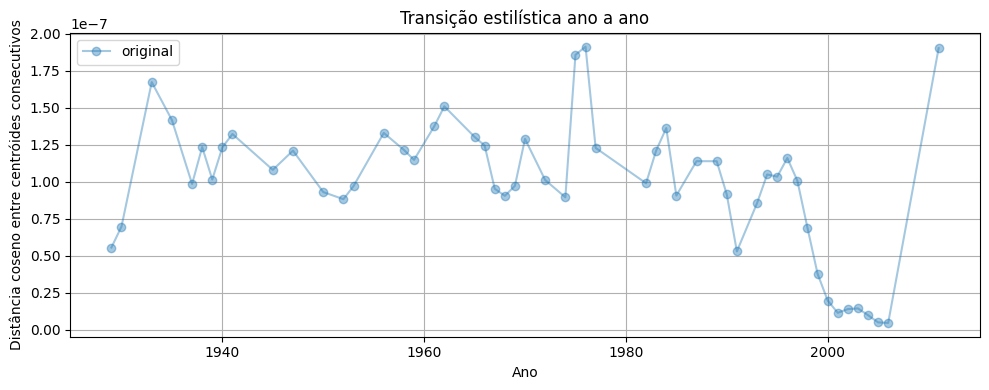

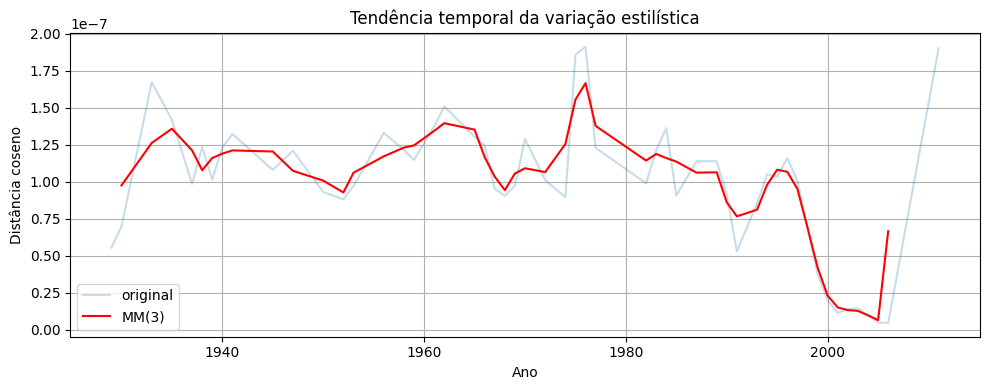

In [222]:
# %% 10. Análise 1: Transição ano a ano

# centróide por ano
cent_ano = df_emb.groupby("ano").mean()
cent_ano_norm = normalize(cent_ano.values)
anos = cent_ano.index.to_list()

transicoes = []
for i in range(len(anos) - 1):
    a1, a2 = anos[i], anos[i+1]
    d = cosine_distances([cent_ano_norm[i]], [cent_ano_norm[i+1]])[0, 0]
    transicoes.append((a1, a2, d))

transicoes_df = pd.DataFrame(transicoes, columns=["ano_1", "ano_2", "distancia"])
transicoes_df["decada"] = (transicoes_df["ano_2"] // 10) * 10

plt.figure(figsize=(10,4))
plt.plot(transicoes_df["ano_2"], transicoes_df["distancia"], marker='o', alpha=0.4, label="original")
plt.title("Transição estilística ano a ano")
plt.xlabel("Ano")
plt.ylabel("Distância coseno entre centróides consecutivos")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# média móvel para suavizar
transicoes_df["dist_suave"] = transicoes_df["distancia"].rolling(window=3, center=True).mean()
plt.figure(figsize=(10,4))
plt.plot(transicoes_df["ano_2"], transicoes_df["distancia"], alpha=0.25, label="original")
plt.plot(transicoes_df["ano_2"], transicoes_df["dist_suave"], color="red", label="MM(3)")
plt.title("Tendência temporal da variação estilística")
plt.xlabel("Ano")
plt.ylabel("Distância coseno")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [219]:
df_emb

,0,1,2,3,4,5,6,7,8,9,...,376,377,378,379,380,381,382,383,ano,decada
0,-0.001283,0.051684,0.053722,0.006443,-0.007643,0.000638,0.102918,-0.006634,0.028293,0.027728,...,0.008890,0.067396,0.071909,-0.024231,0.072643,0.114537,-0.030151,-0.068181,1928,1920
1,0.102386,0.067171,0.033026,0.003745,0.018709,-0.022559,0.019514,0.009322,0.002891,0.003790,...,-0.000861,0.005617,0.036175,-0.034176,0.050505,0.148844,0.005040,0.024707,1929,1920
2,0.009408,0.049569,0.038786,0.021898,-0.018605,-0.008491,0.059189,0.003672,0.081256,0.042544,...,0.065367,0.108239,0.065358,-0.019156,0.135540,0.088179,-0.052427,-0.063275,1929,1920
3,-0.016505,0.000126,0.049142,-0.049449,-0.035629,0.021054,0.118694,0.037955,-0.011957,0.002650,...,0.020452,0.046352,-0.019477,0.009026,0.053513,0.079017,-0.019113,-0.082403,1930,1930
4,0.077407,0.000374,-0.047619,0.009759,0.005430,0.026141,-0.025866,0.007363,0.011935,0.005287,...,0.032272,0.041910,0.092101,-0.044848,0.064766,0.012834,-0.017190,-0.012878,1933,1930
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
163,0.023993,0.056415,0.021560,-0.034929,-0.052753,-0.040362,0.079712,0.008974,0.038355,0.054124,...,0.039052,0.072420,0.030031,0.004467,0.059791,0.114943,-0.020630,-0.058202,2006,2000
164,-0.041868,-0.072858,-0.015010,-0.036706,-0.019907,-0.009242,0.093596,-0.024808,0.076594,-0.014100,...,0.011957,0.036441,-0.029701,0.017235,-0.085335,0.001620,0.024580,-0.026581,2006,2000
165,0.033496,0.030753,0.020687,-0.050702,-0.052637,-0.031729,0.047544,-0.045114,-0.040101,-0.089877,...,0.056642,0.018164,0.079105,0.009082,0.058720,0.044028,-0.034456,0.021882,2006,2000
166,-0.016560,0.057677,-0.017571,-0.082126,-0.061866,-0.018142,0.087883,0.003206,0.056304,0.005739,...,-0.037404,0.053689,0.003981,0.016737,0.045186,0.118232,-0.018359,-0.023532,2006,2000


Correlação transição x variância interna: -0.707


C:\Users\DELL\AppData\Local\Temp\ipykernel_22960\1757810624.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: np.mean(np.var(g.iloc[:, :-2].values, axis=0)))


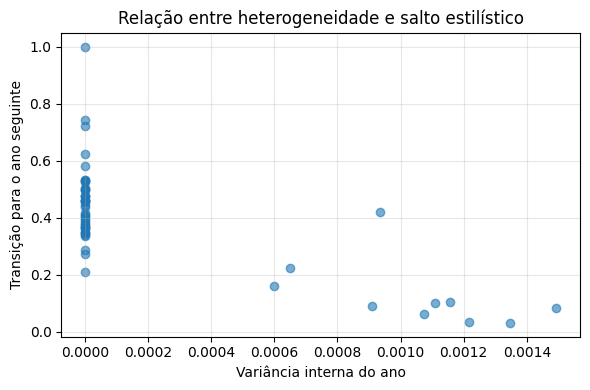

In [189]:
# %% 11. Análise 2: Dispersão interna por ano e correlação

# variância média dos embeddings por ano
variancia_interna = (
    df_emb.groupby("ano")
    .apply(lambda g: np.mean(np.var(g.iloc[:, :-2].values, axis=0)))
    .reset_index(name="variancia_interna")
)

merged = transicoes_df.merge(variancia_interna, left_on="ano_2", right_on="ano")
corr = merged["distancia"].corr(merged["variancia_interna"])
print(f"Correlação transição x variância interna: {corr:.3f}")

plt.figure(figsize=(6,4))
plt.scatter(merged["variancia_interna"], merged["distancia"], alpha=0.6)
plt.xlabel("Variância interna do ano")
plt.ylabel("Transição para o ano seguinte")
plt.title("Relação entre heterogeneidade e salto estilístico")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [190]:
df

,Ano,Mês,Posição,Música,Artista,Gênero
0,1928,Junho,1.0,Carinhoso,Pixinguinha,Choro
1,1929,Fevereiro,1.0,Jura,Mário Reis,Samba-canção
2,1929,Julho,1.0,Gosto Que Me Enrosco,Mário Reis,Samba
3,1930,Fevereiro,1.0,Ta-hí (Pra Você Gostar de Mim),Carmen Miranda,Marchinha
4,1933,Junho,1.0,Cidade Maravilhosa,Aurora Miranda & André Filho,Marcha
...,...,...,...,...,...,...
2487,2000,Agosto,NaN,Spanish Guitar,Toni Braxton,Pop Internacional
2488,2000,Setembro,NaN,Ela Não Está Aqui,KLB,Pop Adolescente
2489,2000,Outubro,NaN,Love by Grace,Lara Fabian,Pop Internacional
2490,2000,Novembro,NaN,Alô,Chitãozinho & Xororó,Sertanejo


In [223]:
# %% 12. Análise 3: Macrotransições por década com janela adaptativa

def macrotransicoes_por_decada(df: pd.DataFrame, base_window: int = 5) -> pd.DataFrame:
    resultados = []
    emb_cols = [c for c in df.columns if c not in ("ano", "decada")]

    for decada, grupo in df.groupby("decada"):
        grupo = grupo.sample(frac=1, random_state=42).reset_index(drop=True)
        n = len(grupo)
        window = max(3, int(base_window * np.sqrt(n / 50)))

        centroides: List[np.ndarray] = []
        for i in range(0, n, window):
            bloco = grupo[emb_cols].iloc[i:i+window]
            if len(bloco) == 0:
                continue
            c = bloco.mean(axis=0).values
            centroides.append(c)

        if not centroides:
            continue

        centroides = np.vstack(centroides)
        centroides = normalize(centroides)

        if len(centroides) > 1:
            dists = cosine_distances(centroides[:-1], centroides[1:])
            diag_dists = [dists[i, i] for i in range(dists.shape[0])]
            media = float(np.mean(diag_dists))
            desvio = float(np.std(diag_dists))
        else:
            media = np.nan
            desvio = np.nan

        resultados.append({
            "decada": decada,
            "n_musicas": n,
            "n_janelas": len(centroides),
            "janela_tam": window,
            "media_macrotransicao": media,
            "desvio_macrotransicao": desvio
        })

    return pd.DataFrame(resultados).sort_values("decada")

macro_df = macrotransicoes_por_decada(df_emb)
macro_df.round(3)

,decada,n_musicas,n_janelas,janela_tam,media_macrotransicao,desvio_macrotransicao
0,1920,3,1,3,NaN,NaN
1,1930,6,2,3,0.160,0.000
2,1940,4,2,3,0.321,0.000
3,1950,6,2,3,0.216,0.000
4,1960,7,3,3,0.289,0.111
5,1970,6,2,3,0.301,0.000
6,1980,7,3,3,0.320,0.030
7,1990,11,4,3,0.173,0.045
8,2000,117,17,7,0.158,0.096
9,2010,1,1,3,NaN,NaN


In [232]:
cent_dec.describe().round(5)

,0,1,2,3,4,5,6,7,8,9,...,375,376,377,378,379,380,381,382,383,ano
count,10.00000,10.00000,10.00000,10.00000,10.00000,10.00000,10.00000,10.00000,10.00000,10.00000,...,10.00000,10.00000,10.00000,10.00000,10.00000,10.00000,10.00000,10.00000,10.00000,10.0
mean,-0.01158,0.02562,0.01053,-0.03070,-0.03797,-0.00330,0.05849,0.00919,0.03860,0.01097,...,-0.02361,0.02101,0.05185,0.01656,-0.01000,0.05210,0.05921,-0.02108,-0.05562,1969.67283
std,0.02791,0.01262,0.01926,0.02194,0.02078,0.02189,0.01678,0.02614,0.02292,0.02132,...,0.03119,0.01243,0.01076,0.04134,0.01294,0.03202,0.04844,0.01225,0.02067,29.05986
min,-0.03967,0.01132,-0.02213,-0.06487,-0.06876,-0.05771,0.03217,-0.01542,-0.01106,-0.03962,...,-0.06019,-0.00538,0.03427,-0.08905,-0.02615,-0.02287,-0.06741,-0.04082,-0.08885,1928.66667
25%,-0.03628,0.01881,0.00497,-0.04222,-0.04835,-0.00956,0.04634,-0.00216,0.02536,0.00381,...,-0.03963,0.01602,0.04274,0.01308,-0.02159,0.04660,0.05906,-0.02679,-0.06873,1946.10417
50%,-0.01965,0.02427,0.00936,-0.03231,-0.03713,0.00041,0.05896,0.00182,0.04432,0.01344,...,-0.03142,0.02086,0.05561,0.02396,-0.00752,0.06314,0.07030,-0.02337,-0.05693,1969.71429
75%,0.01241,0.02884,0.01480,-0.01952,-0.02891,0.01179,0.06981,0.01339,0.05411,0.02541,...,-0.02024,0.02604,0.05983,0.04130,-0.00456,0.07087,0.07668,-0.01773,-0.04010,1992.90909
max,0.03684,0.05614,0.04184,0.01070,-0.00251,0.01828,0.08523,0.07781,0.06419,0.03548,...,0.05492,0.04049,0.06625,0.05781,0.01518,0.08623,0.11719,0.00612,-0.02481,2011.0


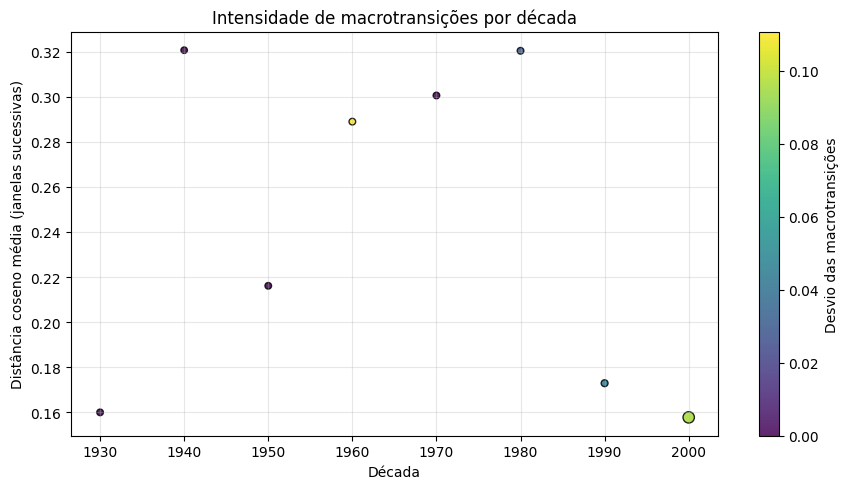

In [234]:
# %% 13. Visualização: dispersão por década

plt.figure(figsize=(9,5))
plt.scatter(
    macro_df["decada"],
    macro_df["media_macrotransicao"],
    s=macro_df["n_musicas"] * 0.4 + 20,
    c=macro_df["desvio_macrotransicao"],
    cmap="viridis",
    edgecolor="k",
    alpha=0.85,
)
plt.colorbar(label="Desvio das macrotransições")
plt.title("Intensidade de macrotransições por década")
plt.xlabel("Década")
plt.ylabel("Distância coseno média (janelas sucessivas)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

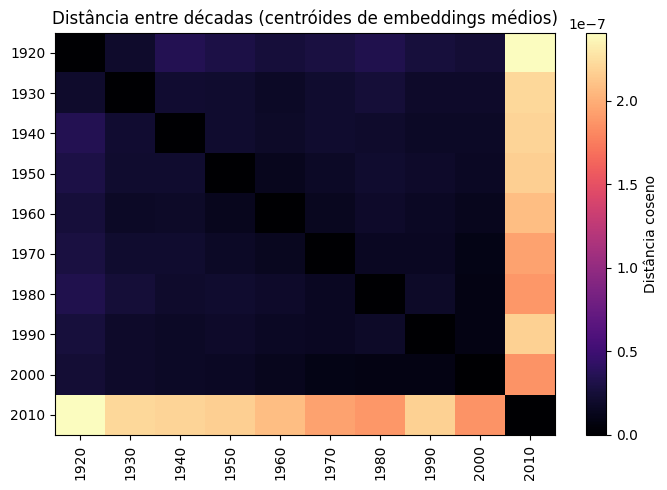

decada,1920,1930,1940,1950,1960,1970,1980,1990,2000,2010
decada,,,,,,,,,,
1920,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1930,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1940,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1950,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1960,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1970,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1980,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1990,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [235]:
# %% 14. Análise 4: Matriz de similaridade entre décadas (corrigida)

# Garantir décadas válidas e com volume suficiente
dec_validas = df_emb["decada"].value_counts()
dec_validas = dec_validas[dec_validas > 5].index  # ignora décadas com poucas músicas
df_dec = df_emb[df_emb["decada"].isin(dec_validas)]

# Cálculo dos centróides sem normalizar duas vezes
cent_dec = df_emb.groupby("decada").mean()
# NÃO normalize aqui
dist_dec = pd.DataFrame(
    cosine_distances(cent_dec.values, cent_dec.values),
    index=cent_dec.index,
    columns=cent_dec.index
)
plt.figure(figsize=(7,5))
plt.imshow(dist_dec, cmap="magma", aspect="auto")
plt.xticks(range(len(dist_dec.columns)), dist_dec.columns, rotation=90)
plt.yticks(range(len(dist_dec.index)), dist_dec.index)
plt.colorbar(label="Distância coseno")
plt.title("Distância entre décadas (centróides de embeddings médios)")
plt.tight_layout()
plt.show()

display(dist_dec.round(3))

In [236]:
# %% 15. Detecção simples de outliers temporais (anos de ruptura)

mean_dist = transicoes_df["distancia"].mean()
std_dist = transicoes_df["distancia"].std()
thr = mean_dist + 2 * std_dist

rupturas = transicoes_df[transicoes_df["distancia"] > thr].copy()
rupturas.sort_values("distancia", ascending=False, inplace=True)

print("Anos com salto estilístico acima de 2σ:")
display(rupturas)


Anos com salto estilístico acima de 2σ:


,ano_1,ano_2,distancia,decada,dist_suave
28,1975,1976,1.912782e-07,1970,1.666194e-07


## Janela Variável


In [175]:
import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import cosine_distances

# --- Agrupa embeddings e metadados
df_emb = pd.DataFrame(emb_matrix).assign(decada=df_corpus["decada"].values)

def macrotransicoes_por_decada(df, base_window=5):
    resultados = []
    emb_cols = [c for c in df.columns if c != "decada"]

    for decada, grupo in df.groupby("decada"):
        grupo = grupo.sample(frac=1, random_state=42).reset_index(drop=True)
        n = len(grupo)
        window = max(3, int(base_window * np.sqrt(n / 50)))

        centroides = []
        for i in range(0, n, window):
            bloco = grupo[emb_cols].iloc[i:i+window]
            if len(bloco) == 0:
                continue
            centroides.append(bloco.mean(axis=0).values)
        centroides = np.vstack(centroides) if centroides else np.empty((0, len(emb_cols)))

        if len(centroides) > 1:
            dists = cosine_distances(centroides[:-1], centroides[1:])
            dist_medias = [dists[i, i] for i in range(len(dists))]
            media_transicao = np.mean(dist_medias)
            desvio_transicao = np.std(dist_medias)
        else:
            media_transicao = np.nan
            desvio_transicao = np.nan

        resultados.append({
            "decada": decada,
            "n_musicas": n,
            "n_janelas": len(centroides),
            "janela_tam": window,
            "media_macrotransicao": media_transicao,
            "desvio_macrotransicao": desvio_transicao
        })

    return pd.DataFrame(resultados).sort_values("decada")

macro_df = macrotransicoes_por_decada(df_emb)
print(macro_df.round(3))

   decada  n_musicas  n_janelas  janela_tam  media_macrotransicao  \
0    1920          3          1           3                   NaN   
1    1930          6          2           3                 0.160   
2    1940          4          2           3                 0.321   
3    1950          6          2           3                 0.216   
4    1960          7          3           3                 0.289   
5    1970          6          2           3                 0.301   
6    1980          7          3           3                 0.320   
7    1990         11          4           3                 0.173   
8    2000        117         17           7                 0.158   
9    2010          1          1           3                   NaN   

   desvio_macrotransicao  
0                    NaN  
1                  0.000  
2                  0.000  
3                  0.000  
4                  0.111  
5                  0.000  
6                  0.030  
7                  0.045

In [176]:
print(df_corpus.columns)
print(df_corpus.head())

Index(['path', 'decada', 'ano', 'artista', 'musica', 'texto'], dtype='object')
                                                path  decada   ano  \
0  data\letras\letras\1920s\1928\Pixinguinha__Car...    1920  1928   
1  data\letras\letras\1920s\1929\Mario_Reis__Gost...    1920  1929   
2  data\letras\letras\1920s\1929\Mario_Reis__Jura...    1920  1929   
3  data\letras\letras\1930s\1930\Carmen_Miranda__...    1930  1930   
4  data\letras\letras\1930s\1933\Aurora_Miranda_e...    1930  1933   

                        artista                          musica  \
0                   Pixinguinha                       Carinhoso   
1                    Mário Reis            Gosto Que Me Enrosco   
2                    Mário Reis                            Jura   
3                Carmen Miranda  Ta-hí (Pra Você Gostar de Mim)   
4  Aurora Miranda & André Filho              Cidade Maravilhosa   

                                               texto  
0  Meu coração, não sei por quê\nBate feli

In [177]:
from sklearn.metrics.pairwise import cosine_distances
import pandas as pd

# --- Cria DataFrame com embeddings e metadados
df_emb = pd.DataFrame(emb_matrix).assign(ano=df_corpus["ano"].values)

# --- Calcula o centróide médio por ano
centroides_anos = df_emb.groupby("ano").mean()

# --- Calcula distâncias entre todos os anos
dist_anos = pd.DataFrame(
    cosine_distances(centroides_anos.values, centroides_anos.values),
    index=centroides_anos.index,
    columns=centroides_anos.index
)

print("Distâncias entre anos — menor = mais parecido:")
dist_anos.round(3)

Distâncias entre anos — menor = mais parecido:


ano,1928,1929,1930,1933,1935,1937,1938,1939,1940,1941,...,1998,1999,2000,2001,2002,2003,2004,2005,2006,2011
ano,,,,,,,,,,,,,,,,,,,,,
1928,0.000,0.226,0.325,0.486,0.346,0.063,0.467,0.343,0.451,0.429,...,0.291,0.211,0.221,0.220,0.224,0.194,0.192,0.173,0.215,1.058
1929,0.226,0.000,0.288,0.441,0.285,0.229,0.319,0.289,0.481,0.414,...,0.308,0.178,0.231,0.207,0.200,0.163,0.174,0.169,0.191,1.083
1930,0.325,0.288,0.000,0.623,0.414,0.296,0.499,0.404,0.384,0.411,...,0.260,0.198,0.231,0.263,0.218,0.258,0.203,0.203,0.185,0.988
1933,0.486,0.441,0.623,0.000,0.528,0.467,0.424,0.327,0.558,0.569,...,0.555,0.478,0.524,0.494,0.508,0.438,0.456,0.482,0.493,1.015
1935,0.346,0.285,0.414,0.528,0.000,0.367,0.475,0.297,0.484,0.427,...,0.383,0.262,0.291,0.283,0.279,0.268,0.261,0.263,0.271,1.063
1937,0.063,0.229,0.296,0.467,0.367,0.000,0.460,0.368,0.451,0.453,...,0.288,0.220,0.236,0.246,0.228,0.203,0.196,0.190,0.227,1.043
1938,0.467,0.319,0.499,0.424,0.475,0.460,0.000,0.378,0.500,0.464,...,0.414,0.352,0.403,0.359,0.408,0.325,0.349,0.356,0.354,1.081
1939,0.343,0.289,0.404,0.327,0.297,0.368,0.378,0.000,0.461,0.460,...,0.392,0.287,0.319,0.309,0.308,0.295,0.303,0.287,0.297,1.071
1940,0.451,0.481,0.384,0.558,0.484,0.451,0.500,0.461,0.000,0.498,...,0.422,0.363,0.345,0.342,0.348,0.381,0.335,0.334,0.309,0.971


In [178]:
# Dispersão interna (variância média dos embeddings de cada ano)
variancia_interna = (
    df_emb.groupby("ano")
    .apply(lambda g: np.mean(np.var(g.iloc[:,:-1].values, axis=0)))
    .reset_index(name="variancia_interna")
)

# Junta com as transições ano a ano
merged = transicoes_df.merge(variancia_interna, left_on="ano_2", right_on="ano")
corr = merged["distancia"].corr(merged["variancia_interna"])
print(f"📈 Correlação entre transição e variância interna: {corr:.3f}")

📈 Correlação entre transição e variância interna: -0.707


C:\Users\DELL\AppData\Local\Temp\ipykernel_22960\3678443811.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: np.mean(np.var(g.iloc[:,:-1].values, axis=0)))
